## Configurazione e montaggio di Google Drive

In [1]:
import os
from pathlib import Path

DEFAULT_REPO_ROOT = Path(
    "/content/drive/MyDrive/Tesi/temporal-event-spiking-research"
)

# In un ambiente locale si può impostare:
# export ETSR_REPO_ROOT=/path/al/repository
REPO_ROOT = Path(os.environ.get("ETSR_REPO_ROOT", DEFAULT_REPO_ROOT))

try:
    shell = get_ipython()
    in_colab = shell is not None and "google.colab" in str(shell)
except NameError:
    in_colab = False

if in_colab:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

if not REPO_ROOT.exists():
    raise FileNotFoundError(
        "Repository non trovato.\n"
        f"Percorso atteso: {REPO_ROOT}\n"
        "Controllare che Google Drive sia montato e che il repository sia in "
        "MyDrive/Tesi/temporal-event-spiking-research, oppure impostare ETSR_REPO_ROOT."
    )

EXPORT_FIGURES = True
FIGURE_DIR = REPO_ROOT / "runs" / "visualization_exports" / "temporal_results_notebook"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository: {REPO_ROOT}")
print(f"Esportazione figure: {EXPORT_FIGURES}")
print(f"Cartella figure: {FIGURE_DIR}")


Mounted at /content/drive
Repository: /content/drive/MyDrive/Tesi/temporal-event-spiking-research
Esportazione figure: True
Cartella figure: /content/drive/MyDrive/Tesi/temporal-event-spiking-research/runs/visualization_exports/temporal_results_notebook


## 1. Import, funzioni di supporto e individuazione automatica degli artifact

In [2]:
import json
import math
import re
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)

def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def pct(value, digits=2):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return "—"
    return f"{100 * float(value):.{digits}f}%"

def pp(value, digits=2):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return "—"
    return f"{100 * float(value):.{digits}f} pp"

def display_percent_table(df: pd.DataFrame, percent_columns=(), digits=2):
    view = df.copy()
    for col in percent_columns:
        if col in view.columns:
            view[col] = view[col].map(
                lambda x: "—" if pd.isna(x) else f"{100 * float(x):.{digits}f}%"
            )
    display(view)

def save_and_show(fig, filename: str):
    fig.tight_layout()
    if EXPORT_FIGURES:
        fig.savefig(FIGURE_DIR / f"{filename}.png", dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def annotate_bars(ax, percent=False, digits=1):
    for container in ax.containers:
        labels = []
        for value in container.datavalues:
            if percent:
                labels.append(f"{100 * value:.{digits}f}%")
            else:
                labels.append(f"{value:.{digits}f}")
        ax.bar_label(container, labels=labels, padding=3, fontsize=9)

def draw_heatmap(
    matrix,
    row_labels,
    col_labels,
    title,
    filename,
    value_format="{:.1%}",
    aspect="auto",
    vmin=None,
    vmax=None,
):
    data = np.asarray(matrix, dtype=float)
    if data.ndim != 2:
        raise ValueError(f"La heatmap richiede una matrice 2D, ricevuta shape={data.shape}.")
    if np.isnan(data).all():
        raise ValueError(
            f"La heatmap '{title}' contiene solo NaN. "
            "Controllare tipi e label usati nel pivot/reindex."
        )

    fig, ax = plt.subplots(
        figsize=(max(7, 1.3 * len(col_labels)), max(4, 0.75 * len(row_labels)))
    )
    image = ax.imshow(data, aspect=aspect, vmin=vmin, vmax=vmax)
    fig.colorbar(image, ax=ax)
    ax.set_xticks(np.arange(len(col_labels)), labels=col_labels)
    ax.set_yticks(np.arange(len(row_labels)), labels=row_labels)
    ax.set_title(title)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            value = data[i, j]
            label = "—" if np.isnan(value) else value_format.format(value)
            ax.text(j, i, label, ha="center", va="center", fontsize=9)

    save_and_show(fig, filename)

def latest_directory(parent: Path, pattern: str):
    candidates = sorted([p for p in parent.glob(pattern) if p.is_dir()])
    if not candidates:
        raise FileNotFoundError(f"Nessuna directory compatibile con {parent / pattern}")
    return candidates[-1]

def parse_seed_from_name(name: str):
    match = re.search(r"seed[_-]?(\d+)", name)
    return int(match.group(1)) if match else None

PHASE1_ARTIFACTS = REPO_ROOT / "runs" / "phase1" / "artifacts"
PHASE2_ARTIFACTS = REPO_ROOT / "runs" / "phase2" / "artifacts"

phase1_run = latest_directory(PHASE1_ARTIFACTS, "*")
phase1_audit = phase1_run / "audit"
phase2_audit = latest_directory(PHASE2_ARTIFACTS, "*__audit__*")

phase2_training_runs = sorted(
    [
        p for p in PHASE2_ARTIFACTS.iterdir()
        if p.is_dir() and "__seed" in p.name and "__audit__" not in p.name
    ],
    key=lambda p: parse_seed_from_name(p.name) or -1,
)

required_paths = [
    phase1_run / "history.csv",
    phase1_run / "test_metrics.json",
    phase1_run / "profile.json",
    phase1_audit / "perturbation_summary.csv",
    phase1_audit / "prefix_curve.csv",
    phase2_audit / "mechanistic_audit_summary.json",
    phase2_audit / "aggregate_prefix.csv",
    phase2_audit / "aggregate_probe.csv",
    phase2_audit / "aggregate_causal.csv",
]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError("Artifact mancanti:\n" + "\n".join(missing))

manifest = pd.DataFrame(
    [
        ["Fase 1 — training", phase1_run.name, str(phase1_run)],
        ["Fase 1 — audit", phase1_audit.name, str(phase1_audit)],
        ["Fase 2 — audit aggregato", phase2_audit.name, str(phase2_audit)],
        *[
            [f"Fase 2 — seed {parse_seed_from_name(p.name)}", p.name, str(p)]
            for p in phase2_training_runs
        ],
    ],
    columns=["componente", "directory_selezionata", "percorso"],
)


# Audit temporale comportamentale


> **La predizione dipende realmente dall'ordine temporale oppure il modello usa soltanto il contenuto medio della sequenza?**

Le principali perturbazioni sono:

- **shuffle temporale:** conserva i frame ma distrugge l'ordine;
- **reverse time:** inverte l'intera dinamica;
- **reverse actions:** scambia le due azioni mantenendo il target originale;
- **reverse actions + reverse target:** valuta la sequenza invertita con la classe invertita.

## 3. Dinamica di addestramento della baseline

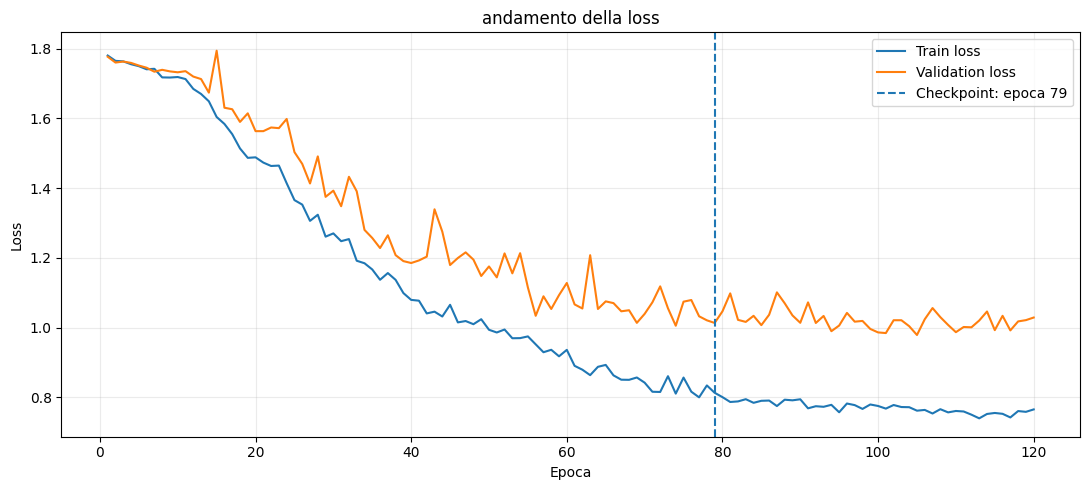

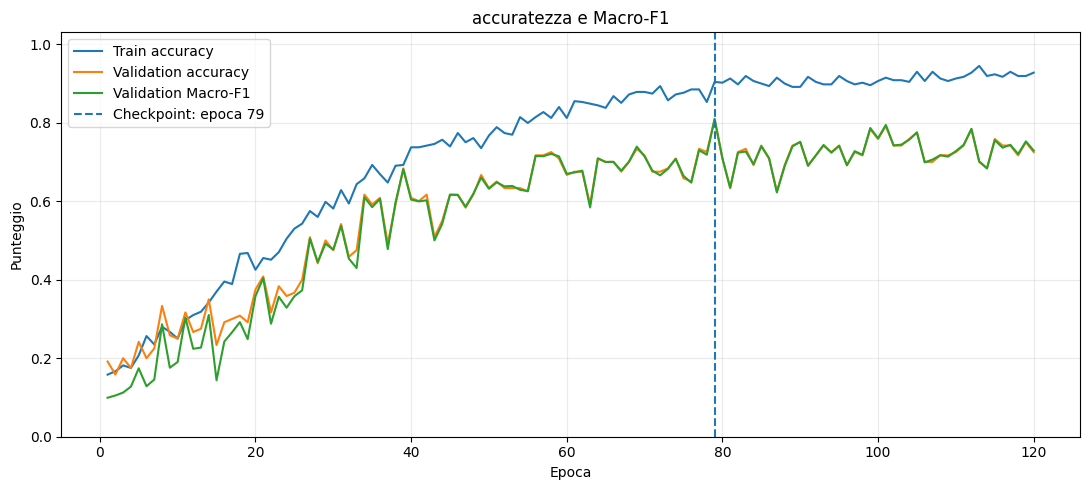

In [3]:
p1_history = pd.read_csv(phase1_run / "history.csv")
p1_summary = load_json(phase1_run / "summary.json")

best_epoch_p1 = int(p1_summary["best_epoch"])
best_score_p1 = float(p1_summary["best_validation_score"])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(p1_history["epoch"], p1_history["train_loss"], label="Train loss")
ax.plot(p1_history["epoch"], p1_history["validation_loss"], label="Validation loss")
ax.axvline(best_epoch_p1, linestyle="--", label=f"Checkpoint: epoca {best_epoch_p1}")
ax.set_xlabel("Epoca")
ax.set_ylabel("Loss")
ax.set_title("andamento della loss")
ax.legend()
ax.grid(alpha=0.25)
save_and_show(fig, "01_phase1_training_loss")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(p1_history["epoch"], p1_history["train_accuracy"], label="Train accuracy")
ax.plot(p1_history["epoch"], p1_history["validation_accuracy"], label="Validation accuracy")
ax.plot(p1_history["epoch"], p1_history["validation_macro_f1"], label="Validation Macro-F1")
ax.axvline(best_epoch_p1, linestyle="--", label=f"Checkpoint: epoca {best_epoch_p1}")
ax.set_xlabel("Epoca")
ax.set_ylabel("Punteggio")
ax.set_ylim(0, 1.03)
ax.set_title("accuratezza e Macro-F1")
ax.legend()
ax.grid(alpha=0.25)
save_and_show(fig, "02_phase1_training_metrics")


## 4. Prestazione standard e matrice di confusione

,Metrica,Valore
0,Accuracy,79.17%
1,Macro-F1,79.31%
2,Loss,0.9171
3,Campioni,144


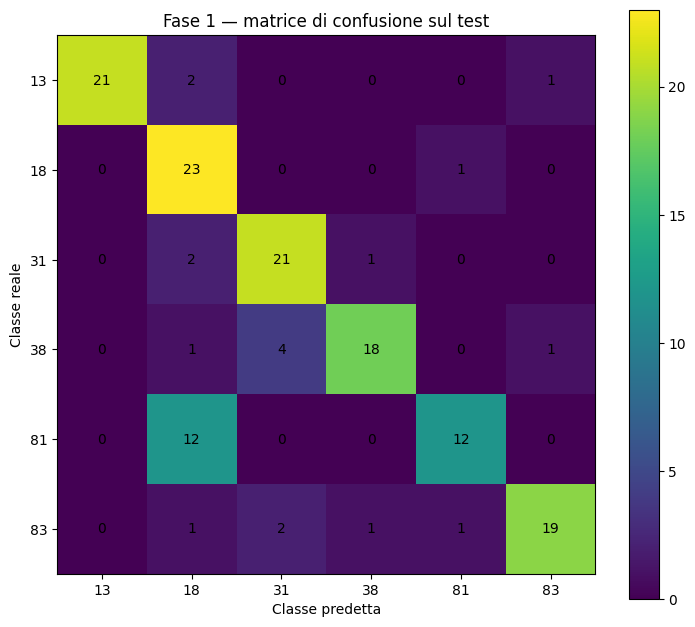

,classe,recall
0,13,87.50%
1,18,95.83%
2,31,87.50%
3,38,75.00%
4,81,50.00%
5,83,79.17%


In [4]:
p1_test = load_json(phase1_run / "test_metrics.json")
dataset_manifest = load_json(phase2_audit / "dataset_manifest.json")
CLASS_NAMES = [str(x) for x in dataset_manifest["classes"]]

p1_metrics_table = pd.DataFrame(
    {
        "Metrica": ["Accuracy", "Macro-F1", "Loss", "Campioni"],
        "Valore": [
            pct(p1_test["accuracy"]),
            pct(p1_test["macro_f1"]),
            f'{p1_test["loss"]:.4f}',
            int(p1_test["samples"]),
        ],
    }
)
display(p1_metrics_table)

cm = np.asarray(p1_test["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7.5, 6.5))
image = ax.imshow(cm)
fig.colorbar(image, ax=ax)
ax.set_xticks(np.arange(len(CLASS_NAMES)), labels=CLASS_NAMES)
ax.set_yticks(np.arange(len(CLASS_NAMES)), labels=CLASS_NAMES)
ax.set_xlabel("Classe predetta")
ax.set_ylabel("Classe reale")
ax.set_title("Fase 1 — matrice di confusione sul test")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")
save_and_show(fig, "03_phase1_confusion_matrix")

recall = np.diag(cm) / cm.sum(axis=1)
recall_table = pd.DataFrame({"classe": CLASS_NAMES, "recall": recall})
display_percent_table(recall_table, ["recall"])

worst_idx = int(np.argmin(recall))


## 5. Effetto delle perturbazioni temporali

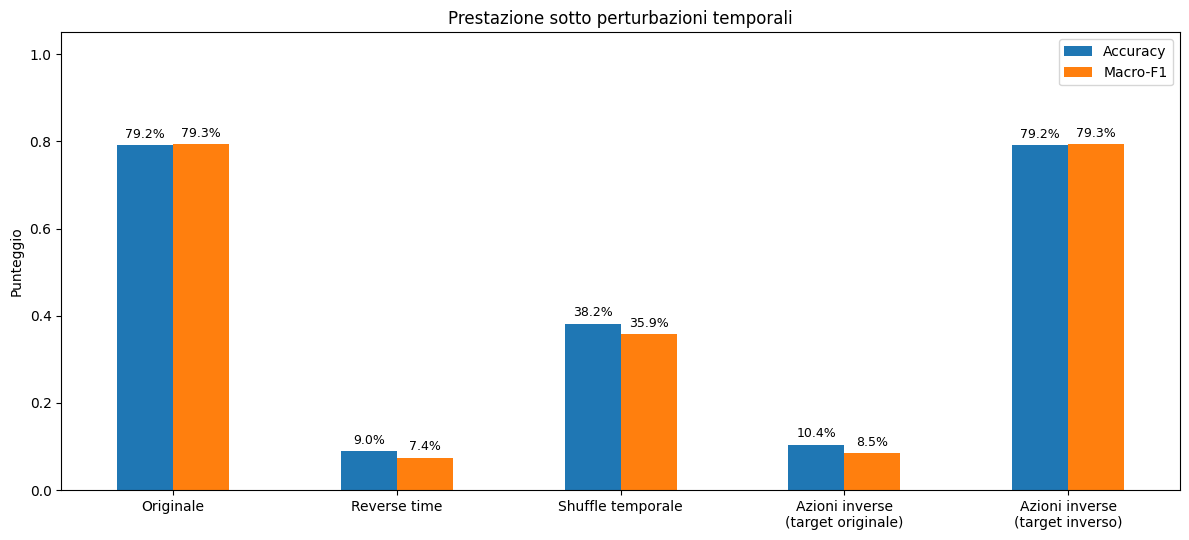

In [5]:
p1_pert = pd.read_csv(phase1_audit / "perturbation_summary.csv")

condition_labels = {
    "original": "Originale",
    "shuffle_time": "Shuffle temporale",
    "reverse_time": "Reverse time",
    "reverse_actions": "Azioni inverse\n(target originale)",
    "reverse_actions__reverse_class": "Azioni inverse\n(target inverso)",
}
p1_pert["label"] = p1_pert["condition"].map(condition_labels).fillna(p1_pert["condition"])

plot_df = p1_pert.set_index("label")[["accuracy", "macro_f1"]]
fig, ax = plt.subplots(figsize=(12, 5.5))
plot_df.plot(kind="bar", ax=ax)
ax.set_ylabel("Punteggio")
ax.set_ylim(0, 1.05)
ax.set_xlabel("")
ax.set_title("Prestazione sotto perturbazioni temporali")
ax.legend(["Accuracy", "Macro-F1"])
ax.tick_params(axis="x", rotation=0)
annotate_bars(ax, percent=True)
save_and_show(fig, "04_phase1_perturbation_performance")


## 6. Separazione tra contenuto e ordine

Per una classe come `13`:

- il **contenuto** è la coppia non ordinata \(\{1,3\}\);
- l'**ordine** distingue `13` da `31`.

Le due metriche sono:

\[
\text{Content Accuracy}
= P\big(c(\hat y)=c(y)\big)
\]

\[
\text{Conditional Order Accuracy}
= P\big(\hat y=y\mid c(\hat y)=c(y)\big).
\]

La seconda metrica risponde a una domanda precisa: **quando il modello ha riconosciuto quali primitive sono presenti, riesce anche a ordinarle?**

,condition,content_accuracy,conditional_order_accuracy
0,Originale,89.58%,88.37%
1,Shuffle temporale,90.97%,41.98%
2,Reverse time,88.89%,10.16%
3,Azioni inverse\n(target originale),89.58%,11.63%


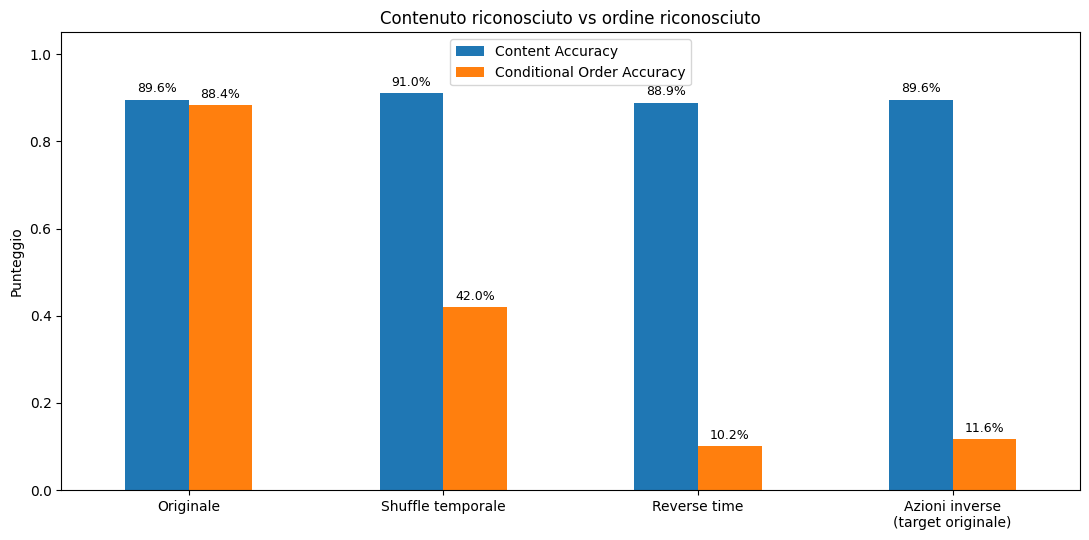

In [6]:
def class_content(label: str):
    return "|".join(sorted(list(str(label))))

def factorized_metrics(targets, predictions, class_names):
    true_labels = np.asarray([class_names[int(i)] for i in targets])
    pred_labels = np.asarray([class_names[int(i)] for i in predictions])
    true_content = np.asarray([class_content(x) for x in true_labels])
    pred_content = np.asarray([class_content(x) for x in pred_labels])
    content_correct = pred_content == true_content
    content_accuracy = float(content_correct.mean())
    conditional_order = (
        float((pred_labels[content_correct] == true_labels[content_correct]).mean())
        if content_correct.any() else np.nan
    )
    return content_accuracy, conditional_order

prediction_files = {
    "original": phase1_audit / "predictions__original.npz",
    "shuffle_time": phase1_audit / "predictions__shuffle_time.npz",
    "reverse_time": phase1_audit / "predictions__reverse_time.npz",
    "reverse_actions": phase1_audit / "predictions__reverse_actions.npz",
}

factorized_rows = []
for condition, path in prediction_files.items():
    arrays = np.load(path)
    content_acc, order_acc = factorized_metrics(
        arrays["targets"], arrays["predictions"], CLASS_NAMES
    )
    factorized_rows.append(
        {
            "condition": condition_labels[condition],
            "content_accuracy": content_acc,
            "conditional_order_accuracy": order_acc,
        }
    )

p1_factorized = pd.DataFrame(factorized_rows)
display_percent_table(
    p1_factorized,
    ["content_accuracy", "conditional_order_accuracy"],
)

fig, ax = plt.subplots(figsize=(11, 5.5))
p1_factorized.set_index("condition")[
    ["content_accuracy", "conditional_order_accuracy"]
].plot(kind="bar", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Punteggio")
ax.set_ylim(0, 1.05)
ax.set_title("Contenuto riconosciuto vs ordine riconosciuto")
ax.legend(["Content Accuracy", "Conditional Order Accuracy"])
ax.tick_params(axis="x", rotation=0)
annotate_bars(ax, percent=True)
save_and_show(fig, "06_phase1_content_vs_order")

original_predictions = np.load(
    phase1_audit / "predictions__original.npz"
)["predictions"]
reverse_predictions = np.load(
    phase1_audit / "predictions__reverse_actions__reverse_class.npz"
)["predictions"]

reverse_index = np.asarray(
    [CLASS_NAMES.index(label[::-1]) for label in CLASS_NAMES]
)
phase1_itc = float(
    np.mean(reverse_predictions == reverse_index[original_predictions])
)

shuffle_row = p1_factorized[p1_factorized["condition"] == "Shuffle temporale"].iloc[0]


## 7. Curva sui prefissi

La rete viene valutata usando solo la parte iniziale della sequenza. La curva indica **quando** l'evidenza discriminativa diventa sufficiente.

L'area normalizzata sotto la curva non coincide con l'accuracy finale: riassume la qualità media della decisione lungo l'intervallo temporale osservato.

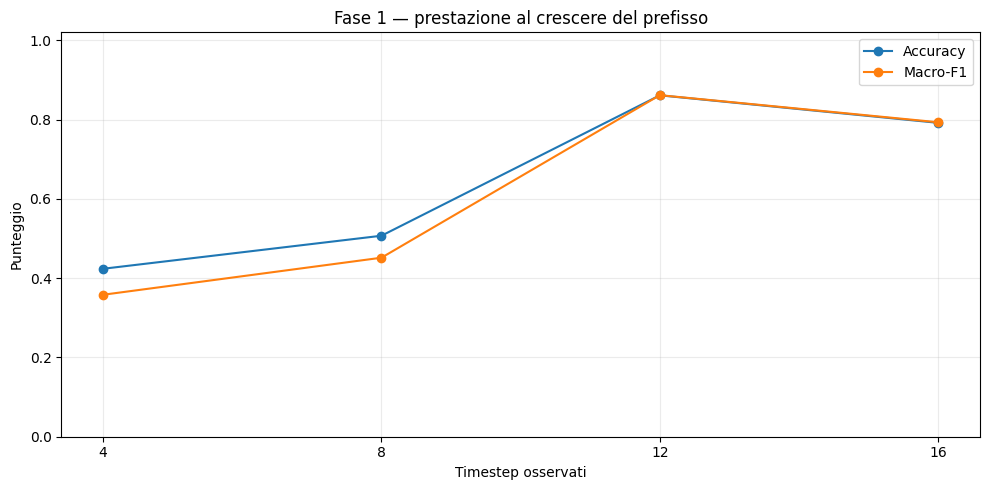

,Timestep osservati,Sequenza osservata,Accuracy,Macro-F1
0,4,25%,42.36%,35.81%
1,8,50%,50.69%,45.15%
2,12,75%,86.11%,86.15%
3,16,100%,79.17%,79.31%


Nota: prefix_curve.csv contiene misure ai timestep 4, 8, 12 e 16; non è presente una misura diretta al timestep 13.


In [7]:
p1_prefix = pd.read_csv(phase1_audit / "prefix_curve.csv")
p1_audit_summary = load_json(phase1_audit / "audit_summary.json")
p1_prefix["timestep"] = np.rint(p1_prefix["fraction"] * 16).astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(p1_prefix["timestep"], p1_prefix["accuracy"], marker="o", label="Accuracy")
ax.plot(p1_prefix["timestep"], p1_prefix["macro_f1"], marker="o", label="Macro-F1")
ax.set_xticks(p1_prefix["timestep"])
ax.set_xlabel("Timestep osservati")
ax.set_ylabel("Punteggio")
ax.set_ylim(0, 1.02)
ax.set_title("Fase 1 — prestazione al crescere del prefisso")
ax.legend()
ax.grid(alpha=0.25)
save_and_show(fig, "07_phase1_prefix_curve")

prefix_table = p1_prefix[["timestep", "fraction", "accuracy", "macro_f1"]].copy()
prefix_table["frazione_sequenza"] = prefix_table["fraction"].map(lambda x: f"{100*x:.0f}%")
prefix_table = prefix_table[
    ["timestep", "frazione_sequenza", "accuracy", "macro_f1"]
].rename(
    columns={
        "timestep": "Timestep osservati",
        "frazione_sequenza": "Sequenza osservata",
        "accuracy": "Accuracy",
        "macro_f1": "Macro-F1",
    }
)
display_percent_table(prefix_table, ["Accuracy", "Macro-F1"])

print(
    "Nota: prefix_curve.csv contiene misure ai timestep 4, 8, 12 e 16; "
    "non è presente una misura diretta al timestep 13."
)

peak_p1 = p1_prefix.loc[p1_prefix["accuracy"].idxmax()]
final_p1 = p1_prefix.iloc[-1]


## 8. Profilo del modello e costo computazionale teorico

Le quantità seguenti hanno significati distinti:

- **parametri:** memoria necessaria per i pesi;
- **firing rate:** quota media di attivazioni spiking non nulle;
- **MAC:** moltiplicazione + accumulo;
- **AC:** semplice accumulo, potenzialmente attivato solo in presenza di spike;
- **energia Horowitz-style:** proxy aritmetica teorica, non misura FPGA reale.

La stima energetica esclude accessi in memoria, routing, clock, controllo e movimento dei dati.

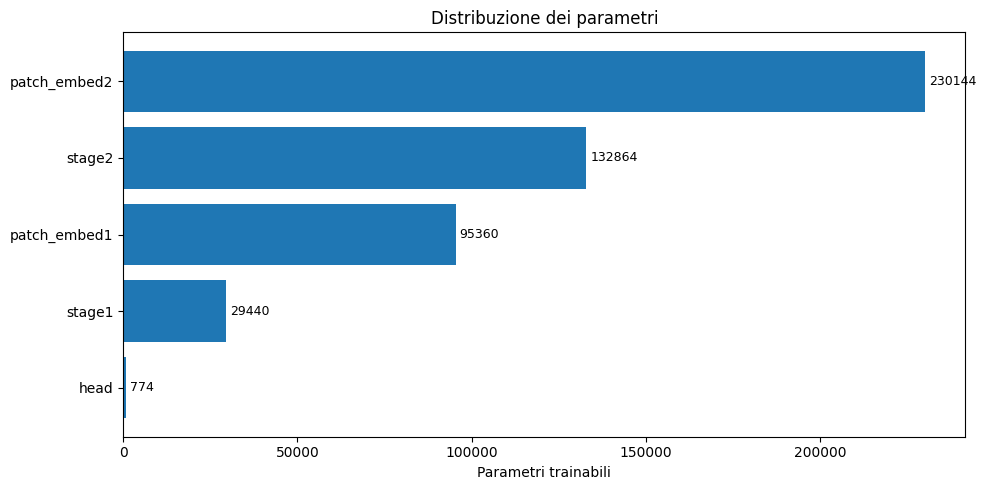

,modulo,parametri,quota
0,head,774,0.16%
3,stage1,29440,6.03%
1,patch_embed1,95360,19.52%
4,stage2,132864,27.19%
2,patch_embed2,230144,47.10%


In [8]:
p1_profile = load_json(phase1_run / "profile.json")
param_breakdown = p1_summary["parameter_breakdown"]

params_df = (
    pd.DataFrame(
        {"modulo": list(param_breakdown.keys()), "parametri": list(param_breakdown.values())}
    )
    .sort_values("parametri")
)
params_df["quota"] = params_df["parametri"] / params_df["parametri"].sum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(params_df["modulo"], params_df["parametri"])
ax.set_xlabel("Parametri trainabili")
ax.set_title("Distribuzione dei parametri")
annotate_bars(ax, percent=False, digits=0)
save_and_show(fig, "08_phase1_parameter_breakdown")

display_percent_table(params_df, ["quota"])

dominant_param = params_df.loc[params_df["parametri"].idxmax()]


In [9]:
ops = p1_profile["operations"]
energy = p1_profile["energy"]

ops_df = pd.DataFrame(
    {
        "Tipo di operazione": ["MAC dense", "AC spike-driven stimate"],
        "Operazioni per campione": [
            int(ops["mac_ops_per_sample"]),
            int(ops["ac_ops_per_sample"]),
        ],
    }
)
ops_df["Milioni per campione"] = ops_df["Operazioni per campione"] / 1e6
ops_df["Quota sul totale"] = (
    ops_df["Operazioni per campione"] / ops_df["Operazioni per campione"].sum()
)

ops_total = pd.DataFrame(
    {
        "Tipo di operazione": ["Totale"],
        "Operazioni per campione": [int(ops_df["Operazioni per campione"].sum())],
        "Milioni per campione": [ops_df["Milioni per campione"].sum()],
        "Quota sul totale": [1.0],
    }
)
ops_table = pd.concat([ops_df, ops_total], ignore_index=True)
ops_table["Operazioni per campione"] = ops_table["Operazioni per campione"].map(
    lambda x: f"{x:,}"
)
ops_table["Milioni per campione"] = ops_table["Milioni per campione"].map(
    lambda x: f"{x:.2f}"
)
display_percent_table(ops_table, ["Quota sul totale"])

energy_df = pd.DataFrame(
    {
        "Componente energetica": ["Energia MAC", "Energia AC"],
        "Energia per campione (mJ)": [
            energy["mac_energy_pj"] / 1e9,
            energy["ac_energy_pj"] / 1e9,
        ],
    }
)
energy_df["Quota sul totale"] = (
    energy_df["Energia per campione (mJ)"]
    / energy_df["Energia per campione (mJ)"].sum()
)

energy_total = pd.DataFrame(
    {
        "Componente energetica": ["Totale teorico"],
        "Energia per campione (mJ)": [energy_df["Energia per campione (mJ)"].sum()],
        "Quota sul totale": [1.0],
    }
)
energy_table = pd.concat([energy_df, energy_total], ignore_index=True)
energy_table["Energia per campione (mJ)"] = energy_table[
    "Energia per campione (mJ)"
].map(lambda x: f"{x:.4f}")
display_percent_table(energy_table, ["Quota sul totale"])


,Tipo di operazione,Operazioni per campione,Milioni per campione,Quota sul totale
0,MAC dense,"150,995,712",151.00,64.22%
1,AC spike-driven stimate,"84,118,708",84.12,35.78%
2,Totale,"235,114,420",235.11,100.00%


,Componente energetica,Energia per campione (mJ),Quota sul totale
0,Energia MAC,0.6946,90.17%
1,Energia AC,0.0757,9.83%
2,Totale teorico,0.7703,100.00%


In [10]:
firing = p1_profile["firing"]
firing_df = pd.DataFrame(
    list(firing["layer_firing_rates"].items()),
    columns=["Layer LIF", "Firing rate"],
).sort_values("Firing rate", ascending=False)

firing_summary = pd.DataFrame(
    {
        "Indicatore": [
            "Firing rate globale",
            "Media aritmetica dei layer",
            "Minimo tra i layer",
            "Massimo tra i layer",
            "Numero di layer profilati",
        ],
        "Valore": [
            firing["global_firing_rate"],
            firing_df["Firing rate"].mean(),
            firing_df["Firing rate"].min(),
            firing_df["Firing rate"].max(),
            len(firing_df),
        ],
    }
)

firing_summary_display = firing_summary.copy()
for row in range(4):
    firing_summary_display.loc[row, "Valore"] = pct(
        firing_summary_display.loc[row, "Valore"]
    )
firing_summary_display.loc[4, "Valore"] = int(
    firing_summary_display.loc[4, "Valore"]
)
display(firing_summary_display)

display_percent_table(firing_df.reset_index(drop=True), ["Firing rate"])

print(
    "Il firing rate globale non è la media semplice dei firing rate dei layer: "
    f"nel profilo è calcolato come '{firing['aggregation']}'. "
    "Ogni elemento prodotto dai layer LIF ha quindi lo stesso peso; i layer con tensor "
    "più grandi incidono maggiormente. Inoltre, il precedente grafico mostrava soltanto "
    "i 12 layer con firing rate più alto e nascondeva i layer sotto il 3,6%."
)


,Indicatore,Valore
0,Firing rate globale,3.40%
1,Media aritmetica dei layer,7.01%
2,Minimo tra i layer,0.40%
3,Massimo tra i layer,27.53%
4,Numero di layer profilati,24


,Layer LIF,Firing rate
0,patch_embed2.output_lif,27.53%
1,stage2.attention.proj_lif,19.67%
2,stage2.mlp.fc2.lif,14.73%
3,stage2.attention_residual_lif,14.41%
4,stage1.attention.attn_lif,12.56%
5,stage2.mlp_residual_lif,10.50%
6,stage2.mlp.fc1.lif,8.01%
7,stage2.attention.attn_lif,7.99%
8,stage2.attention.q_lif,7.80%
9,stage2.attention.k_lif,5.55%


Il firing rate globale non è la media semplice dei firing rate dei layer: nel profilo è calcolato come 'element-weighted across profiled LIF outputs'. Ogni elemento prodotto dai layer LIF ha quindi lo stesso peso; i layer con tensor più grandi incidono maggiormente. Inoltre, il precedente grafico mostrava soltanto i 12 layer con firing rate più alto e nascondeva i layer sotto il 3,6%.



Il **firing rate globale** è quindi compatibile con i valori per-layer: non è la media delle percentuali mostrate, ma una media pesata per il numero di elementi prodotti da ciascun layer LIF. Un layer con una feature map molto grande pesa più di un layer con pochi elementi. La tabella completa mostra inoltre diversi layer con firing rate inferiore al 3,6%, che il precedente grafico “top-12” non visualizzava.


## 10. Replica multi-seed: addestramento e generalizzazione

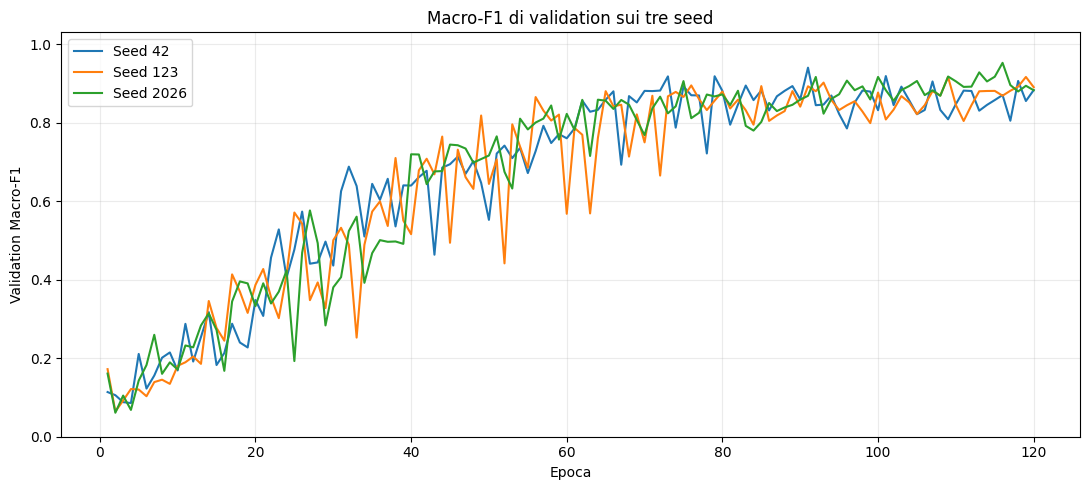

,seed,best_epoch,validation_macro_f1,audit_accuracy,audit_macro_f1,content_accuracy,conditional_order_accuracy,validation_audit_gap
0,42,91,94.00%,72.92%,72.86%,79.17%,92.11%,21.15%
1,123,119,91.63%,67.71%,68.06%,72.92%,92.86%,23.57%
2,2026,116,95.23%,62.50%,63.97%,70.83%,88.24%,31.26%


In [11]:
phase2_histories = []
training_summary_rows = []

seed_audit_summaries = {
    int(path.name.split("_")[-1]): load_json(path / "seed_summary.json")
    for path in phase2_audit.glob("seed_*")
}

for run in phase2_training_runs:
    seed = parse_seed_from_name(run.name)
    history = pd.read_csv(run / "history.csv")
    history["seed"] = seed
    phase2_histories.append(history)
    run_summary = load_json(run / "summary.json")
    audit_summary = seed_audit_summaries[seed]
    training_summary_rows.append(
        {
            "seed": seed,
            "best_epoch": int(run_summary["best_epoch"]),
            "validation_macro_f1": float(run_summary["best_validation_score"]),
            "audit_accuracy": float(audit_summary["accuracy"]),
            "audit_macro_f1": float(audit_summary["macro_f1"]),
            "content_accuracy": float(audit_summary["content_accuracy"]),
            "conditional_order_accuracy": float(audit_summary["conditional_order_accuracy"]),
        }
    )

phase2_history = pd.concat(phase2_histories, ignore_index=True)
phase2_training_summary = pd.DataFrame(training_summary_rows).sort_values("seed")
phase2_training_summary["validation_audit_gap"] = (
    phase2_training_summary["validation_macro_f1"]
    - phase2_training_summary["audit_macro_f1"]
)

fig, ax = plt.subplots(figsize=(11, 5))
for seed, group in phase2_history.groupby("seed"):
    ax.plot(group["epoch"], group["validation_macro_f1"], label=f"Seed {seed}")
ax.set_xlabel("Epoca")
ax.set_ylabel("Validation Macro-F1")
ax.set_ylim(0, 1.03)
ax.set_title("Macro-F1 di validation sui tre seed")
ax.legend()
ax.grid(alpha=0.25)
save_and_show(fig, "12_phase2_validation_training")

display_percent_table(
    phase2_training_summary,
    [
        "validation_macro_f1",
        "audit_accuracy",
        "audit_macro_f1",
        "content_accuracy",
        "conditional_order_accuracy",
        "validation_audit_gap",
    ],
)


## 12. Quali coppie sono più facili? Contenuto, ordine e inversione

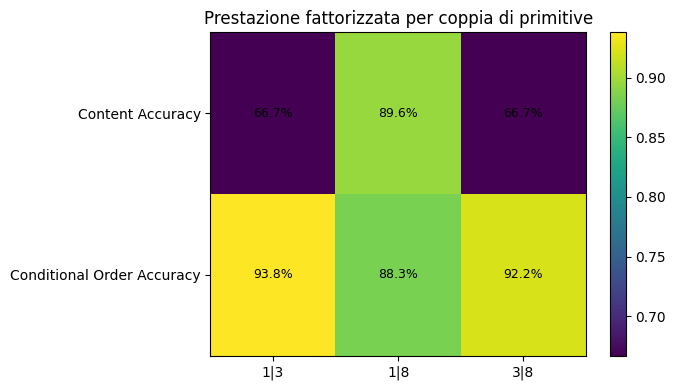

,content,content_accuracy_mean,content_accuracy_std,conditional_order_accuracy_mean,conditional_order_accuracy_std
0,1|3,66.67%,10.05%,93.82%,5.50%
1,1|8,89.58%,3.61%,88.33%,5.55%
2,3|8,66.67%,4.77%,92.18%,2.73%


In [12]:
content_pair = pd.read_csv(phase2_audit / "aggregate_content_pair.csv")

pair_matrix = content_pair.set_index("content")[
    ["content_accuracy_mean", "conditional_order_accuracy_mean"]
].T

draw_heatmap(
    pair_matrix.values,
    ["Content Accuracy", "Conditional Order Accuracy"],
    pair_matrix.columns.tolist(),
    "Prestazione fattorizzata per coppia di primitive",
    "15_phase2_content_pair_heatmap",
)

display_percent_table(
    content_pair[
        [
            "content",
            "content_accuracy_mean",
            "content_accuracy_std",
            "conditional_order_accuracy_mean",
            "conditional_order_accuracy_std",
        ]
    ],
    [
        "content_accuracy_mean",
        "content_accuracy_std",
        "conditional_order_accuracy_mean",
        "conditional_order_accuracy_std",
    ],
)

best_content = content_pair.loc[content_pair["content_accuracy_mean"].idxmax()]



### Coerenza delle coppie matched sotto inversione

La visualizzazione seguente confronta quattro quantità per ciascuna coppia di primitive, ad esempio \(1|3\):

- **ITC — Inverse Temporal Consistency:** quota di coppie matched per cui la predizione su \(BA\) è esattamente l'inversa della predizione ottenuta su \(AB\). Non richiede che la predizione su \(AB\) sia corretta: misura la coerenza della trasformazione.
- **Accuracy canonica:** accuracy sugli input nell'orientazione originale \(AB\).
- **Accuracy con target inverso:** accuracy sugli input matched \(BA\), valutati con l'etichetta inversa.
- **Joint Pair Accuracy:** quota di coppie per cui **entrambe** le orientazioni, \(AB\) e \(BA\), sono classificate correttamente.

La ITC risponde quindi alla domanda *«invertendo l'ordine dell'input, la decisione si inverte in modo coerente?»*; la Joint Pair Accuracy è più severa, perché richiede anche la correttezza di entrambe le predizioni.


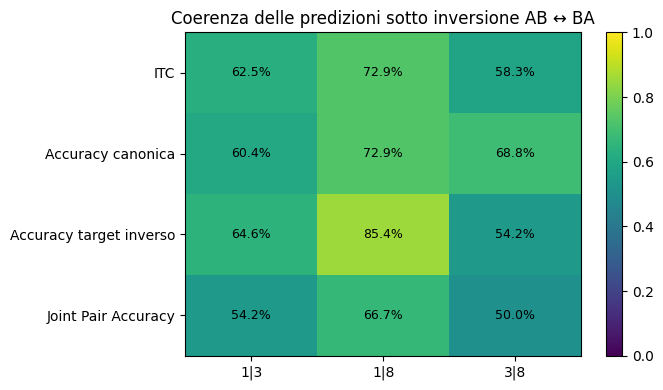

,Coppia,ITC,Accuracy canonica,Accuracy target inverso,Joint Pair Accuracy
0,1|3,62.50%,60.42%,64.58%,54.17%
1,1|8,72.92%,72.92%,85.42%,66.67%
2,3|8,58.33%,68.75%,54.17%,50.00%


In [13]:
inverse_pair = pd.read_csv(phase2_audit / "aggregate_inverse_pair.csv")

inverse_matrix = inverse_pair.set_index("content")[
    [
        "inverse_temporal_consistency_mean",
        "canonical_accuracy_mean",
        "reverse_target_accuracy_mean",
        "joint_pair_accuracy_mean",
    ]
].T

draw_heatmap(
    inverse_matrix.values,
    [
        "ITC",
        "Accuracy canonica",
        "Accuracy target inverso",
        "Joint Pair Accuracy",
    ],
    inverse_matrix.columns.tolist(),
    "Coerenza delle predizioni sotto inversione AB ↔ BA",
    "16_phase2_inverse_pair_heatmap",
    vmin=0,
    vmax=1,
)

inverse_table = inverse_pair[
    [
        "content",
        "inverse_temporal_consistency_mean",
        "canonical_accuracy_mean",
        "reverse_target_accuracy_mean",
        "joint_pair_accuracy_mean",
    ]
].rename(
    columns={
        "content": "Coppia",
        "inverse_temporal_consistency_mean": "ITC",
        "canonical_accuracy_mean": "Accuracy canonica",
        "reverse_target_accuracy_mean": "Accuracy target inverso",
        "joint_pair_accuracy_mean": "Joint Pair Accuracy",
    }
)
display_percent_table(
    inverse_table,
    ["ITC", "Accuracy canonica", "Accuracy target inverso", "Joint Pair Accuracy"],
)

weakest_inverse = inverse_pair.loc[
    inverse_pair["inverse_temporal_consistency_mean"].idxmin()
]


## 13. Sensibilità alla durata relativa delle due azioni

,ratio,accuracy_mean,content_accuracy_mean,conditional_order_accuracy_mean,prediction_consistency_mean
0,0.4:0.6,67.71%,77.43%,87.36%,80.56%
1,0.6:0.4,63.89%,66.67%,95.86%,81.25%


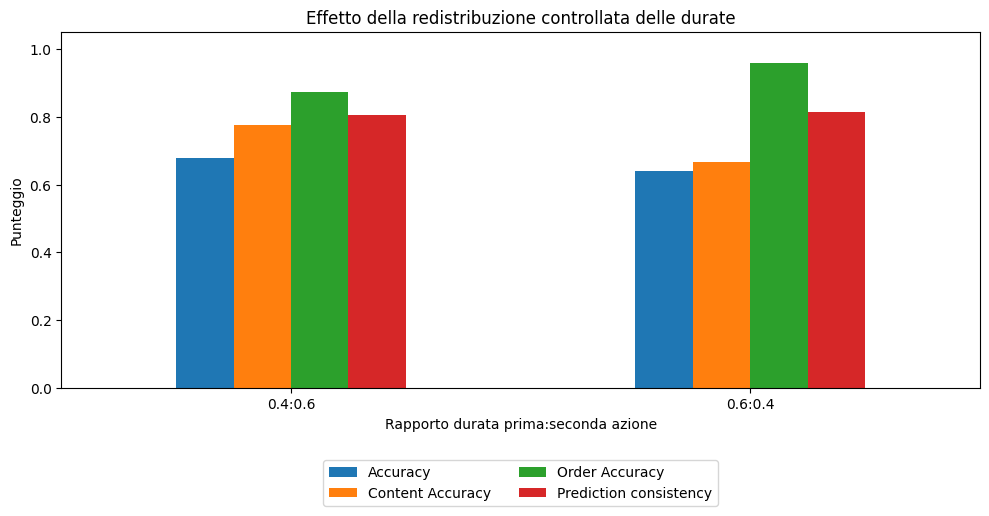

In [14]:
transformations = pd.read_csv(phase2_audit / "aggregate_transformation.csv")

duration_view = transformations[
    [
        "ratio",
        "accuracy_mean",
        "content_accuracy_mean",
        "conditional_order_accuracy_mean",
        "prediction_consistency_mean",
    ]
].copy()

display_percent_table(
    duration_view,
    [
        "accuracy_mean",
        "content_accuracy_mean",
        "conditional_order_accuracy_mean",
        "prediction_consistency_mean",
    ],
)

fig, ax = plt.subplots(figsize=(10, 5.5))
duration_view.set_index("ratio")[
    [
        "accuracy_mean",
        "content_accuracy_mean",
        "conditional_order_accuracy_mean",
        "prediction_consistency_mean",
    ]
].plot(kind="bar", ax=ax)
ax.set_xlabel("Rapporto durata prima:seconda azione")
ax.set_ylabel("Punteggio")
ax.set_ylim(0, 1.05)
ax.set_title("Effetto della redistribuzione controllata delle durate")
ax.legend(
    ["Accuracy", "Content Accuracy", "Order Accuracy", "Prediction consistency"],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=2,
)
ax.tick_params(axis="x", rotation=0)
save_and_show(fig, "17_phase2_duration_redistribution")

mean_changed = 1 - transformations["prediction_consistency_mean"].mean()


## 14. Che cosa è visibile direttamente nell'input?

`input_temporal_statistics.csv` contiene, per ogni campione e timestep:

- conteggio totale degli eventi;
- conteggi ON e OFF;
- rapporto di polarità;
- variazione L1 rispetto al frame precedente;
- centroide spaziale \(x,y\).

Le visualizzazioni seguenti mostrano quanto le classi siano già distinguibili tramite statistiche di basso livello.

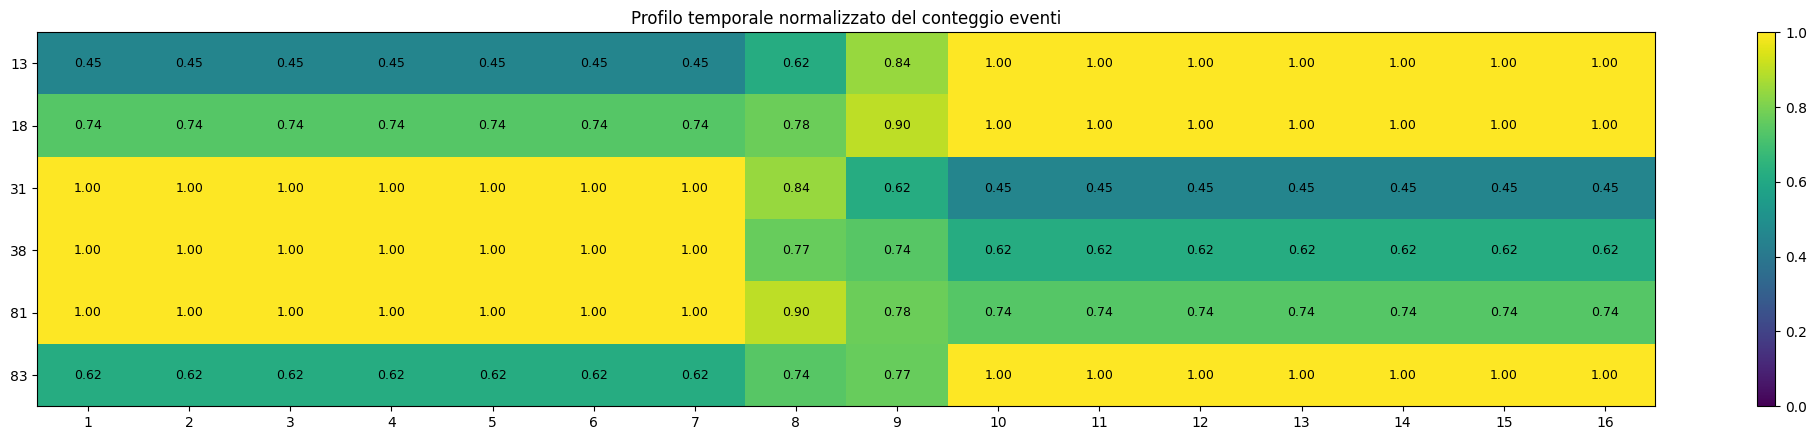

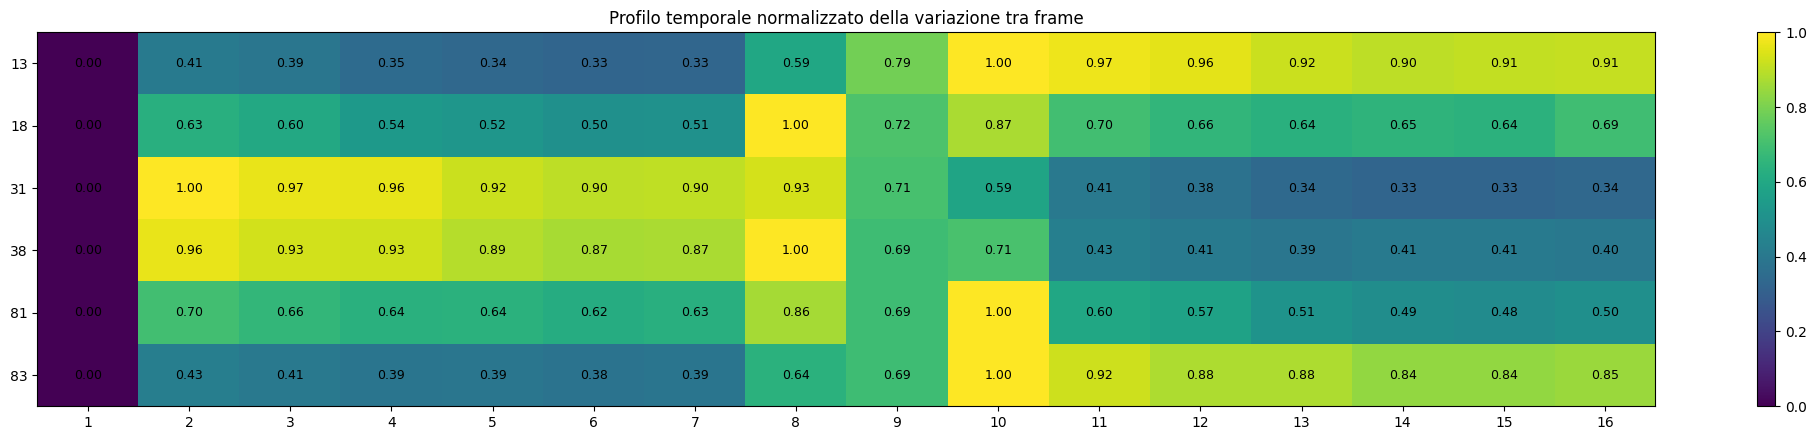

In [15]:
stats_files = sorted(phase2_audit.glob("seed_*/input_temporal_statistics.csv"))
input_stats = pd.read_csv(stats_files[0])

# class_name viene salvata nel CSV come intero, mentre CLASS_NAMES contiene stringhe.
# La conversione esplicita evita che reindex(CLASS_NAMES) produca una matrice tutta NaN.
input_stats["class_name"] = input_stats["class_name"].astype(str)
input_stats["timestep"] = pd.to_numeric(input_stats["timestep"], errors="raise").astype(int)

event_heat = input_stats.pivot_table(
    index="class_name",
    columns="timestep",
    values="event_count",
    aggfunc="mean",
).reindex(index=CLASS_NAMES, columns=range(1, 17))

# Normalizzazione per classe: evidenzia la forma temporale, non la scala assoluta.
event_scale = event_heat.max(axis=1).replace(0, np.nan)
event_heat_norm = event_heat.div(event_scale, axis=0)

draw_heatmap(
    event_heat_norm.values,
    event_heat_norm.index.tolist(),
    [str(int(x)) for x in event_heat_norm.columns],
    "Profilo temporale normalizzato del conteggio eventi",
    "18_phase2_input_event_count_heatmap",
    value_format="{:.2f}",
    vmin=0,
    vmax=1,
)

diff_heat = input_stats.pivot_table(
    index="class_name",
    columns="timestep",
    values="frame_difference_l1",
    aggfunc="mean",
).reindex(index=CLASS_NAMES, columns=range(1, 17))

diff_scale = diff_heat.max(axis=1).replace(0, np.nan)
diff_heat_norm = diff_heat.div(diff_scale, axis=0)

draw_heatmap(
    diff_heat_norm.values,
    diff_heat_norm.index.tolist(),
    [str(int(x)) for x in diff_heat_norm.columns],
    "Profilo temporale normalizzato della variazione tra frame",
    "19_phase2_input_frame_difference_heatmap",
    value_format="{:.2f}",
    vmin=0,
    vmax=1,
)


## 15. Baseline lineari: statistiche tempo-dipendenti vs tempo-indipendenti

In [16]:
shortcut = pd.read_csv(phase2_audit / "aggregate_shortcut.csv")
shortcut_labels = {
    "temporal_input_statistics": "Statistiche tempo-dipendenti",
    "order_invariant_input_statistics": "Statistiche tempo-indipendenti",
}
shortcut["label"] = shortcut["probe"].map(shortcut_labels)

shortcut_view = shortcut[
    [
        "label",
        "audit_accuracy_mean",
        "content_accuracy_mean",
        "conditional_order_accuracy_mean",
        "shuffled_label_accuracy_mean",
    ]
].copy()

display_percent_table(
    shortcut_view,
    [
        "accuracy_mean",
        "content_accuracy_mean",
        "conditional_order_accuracy_mean",
        "shuffled_label_accuracy_mean",
    ],
)


,label,audit_accuracy_mean,content_accuracy_mean,conditional_order_accuracy_mean,shuffled_label_accuracy_mean
0,Statistiche tempo-indipendenti,0.388889,77.78%,50.00%,23.61%
1,Statistiche tempo-dipendenti,0.930556,93.06%,100.00%,17.71%


## 16. Come si costruisce la decisione lungo i 16 timestep?

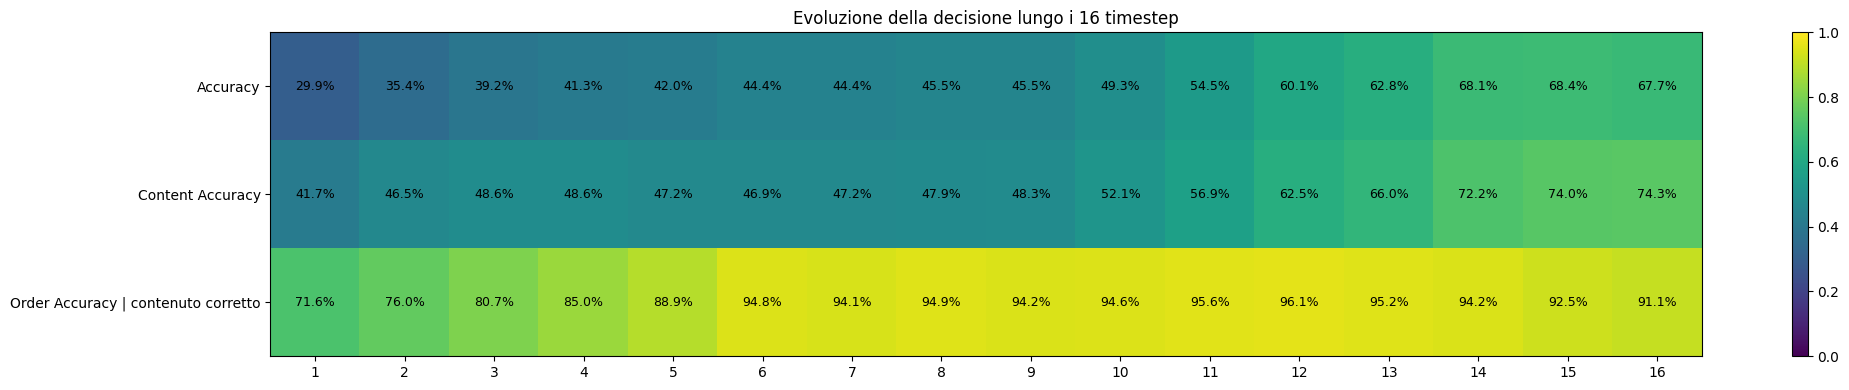

,Timestep,Accuracy media,Std accuracy,Content Accuracy,Order Accuracy | contenuto
0,1,29.86%,2.62%,41.67%,71.59%
3,4,41.32%,4.21%,48.61%,84.95%
7,8,45.49%,1.59%,47.92%,94.93%
9,10,49.31%,4.81%,52.08%,94.61%
11,12,60.07%,4.21%,62.50%,96.06%
13,14,68.06%,5.92%,72.22%,94.16%
15,16,67.71%,5.21%,74.31%,91.07%


In [17]:
aggregate_prefix = pd.read_csv(phase2_audit / "aggregate_prefix.csv")
aggregate_prefix["timestep"] = pd.to_numeric(
    aggregate_prefix["timestep"], errors="raise"
).astype(int)
aggregate_prefix = aggregate_prefix.sort_values("timestep").reset_index(drop=True)

prefix_metrics_heat = aggregate_prefix.set_index("timestep")[
    [
        "accuracy_mean",
        "content_accuracy_mean",
        "conditional_order_accuracy_mean",
    ]
].T

draw_heatmap(
    prefix_metrics_heat.values,
    ["Accuracy", "Content Accuracy", "Order Accuracy | contenuto corretto"],
    [str(int(x)) for x in prefix_metrics_heat.columns],
    "Evoluzione della decisione lungo i 16 timestep",
    "21_phase2_prefix_metrics",
    vmin=0,
    vmax=1,
)

selected_timesteps = [1, 4, 8, 10, 12, 14, 16]
prefix_selected = aggregate_prefix[
    aggregate_prefix["timestep"].isin(selected_timesteps)
][
    [
        "timestep",
        "accuracy_mean",
        "accuracy_std",
        "content_accuracy_mean",
        "conditional_order_accuracy_mean",
    ]
].rename(
    columns={
        "timestep": "Timestep",
        "accuracy_mean": "Accuracy media",
        "accuracy_std": "Std accuracy",
        "content_accuracy_mean": "Content Accuracy",
        "conditional_order_accuracy_mean": "Order Accuracy | contenuto",
    }
)
display_percent_table(
    prefix_selected,
    [
        "Accuracy media",
        "Std accuracy",
        "Content Accuracy",
        "Order Accuracy | contenuto",
    ],
)

peak_prefix = aggregate_prefix.loc[aggregate_prefix["accuracy_mean"].idxmax()]
final_prefix = aggregate_prefix.iloc[-1]


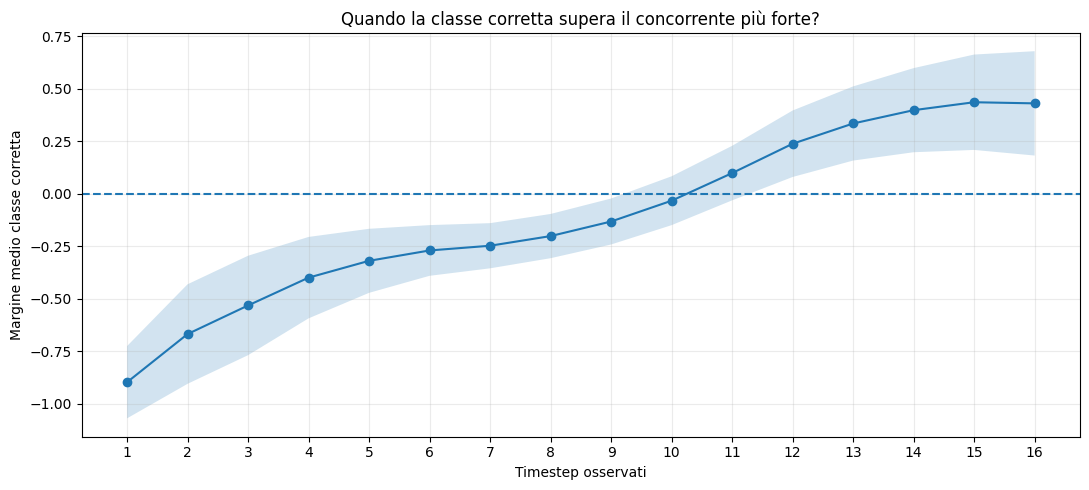

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    aggregate_prefix["timestep"],
    aggregate_prefix["mean_correct_margin_mean"],
    marker="o",
)
ax.fill_between(
    aggregate_prefix["timestep"],
    aggregate_prefix["mean_correct_margin_mean"] - aggregate_prefix["mean_correct_margin_std"],
    aggregate_prefix["mean_correct_margin_mean"] + aggregate_prefix["mean_correct_margin_std"],
    alpha=0.2,
)
ax.axhline(0, linestyle="--")
ax.set_xticks(range(1, 17))
ax.set_xlabel("Timestep osservati")
ax.set_ylabel("Margine medio classe corretta")
ax.set_title("Quando la classe corretta supera il concorrente più forte?")
ax.grid(alpha=0.25)
save_and_show(fig, "22_phase2_correct_margin")

positive_margin = aggregate_prefix[
    aggregate_prefix["mean_correct_margin_mean"] > 0
]
first_positive = (
    int(positive_margin["timestep"].iloc[0]) if not positive_margin.empty else None
)


## 17. Late Harm, Late Rescue e Net Late Utility

Tra due prefissi:

- **Late Harm:** campione corretto che diventa errato;
- **Late Rescue:** campione errato che diventa corretto;
- **Net Late Utility:**

\[
\text{NLU} = \text{Rescue Rate} - \text{Harm Rate}.
\]

Una NLU positiva indica che l'informazione tardiva è mediamente utile.

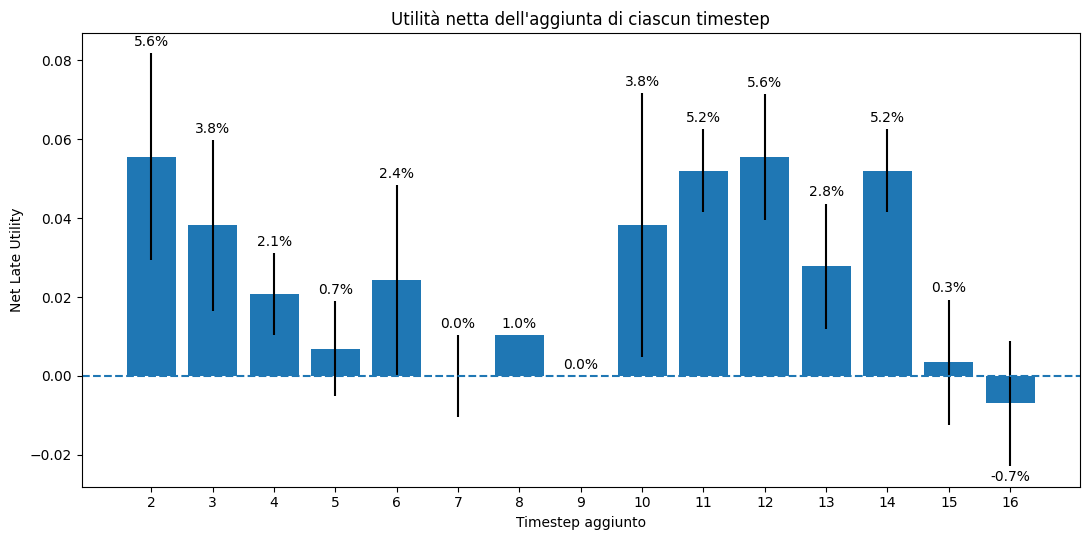

,intervallo,Late Harm,Late Rescue,Net Late Utility,std NLU
0,12 → 16,6.94%,14.58%,7.64%,2.62%


In [19]:
late_update = pd.read_csv(phase2_audit / "aggregate_late_update.csv")
consecutive = late_update[
    late_update["to_timestep"] == late_update["from_timestep"] + 1
].sort_values("to_timestep")

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(
    consecutive["to_timestep"].astype(str),
    consecutive["net_late_utility_mean"],
    yerr=consecutive["net_late_utility_std"],
)
ax.axhline(0, linestyle="--")
ax.set_xlabel("Timestep aggiunto")
ax.set_ylabel("Net Late Utility")
ax.set_title("Utilità netta dell'aggiunta di ciascun timestep")
ax.bar_label(bars, labels=[pct(v, 1) for v in consecutive["net_late_utility_mean"]], padding=3)
save_and_show(fig, "23_phase2_net_late_utility")

tail_12_16 = late_update[
    (late_update["from_timestep"] == 12)
    & (late_update["to_timestep"] == 16)
].iloc[0]

tail_table = pd.DataFrame(
    {
        "intervallo": ["12 → 16"],
        "Late Harm": [tail_12_16["late_harm_rate_mean"]],
        "Late Rescue": [tail_12_16["late_rescue_rate_mean"]],
        "Net Late Utility": [tail_12_16["net_late_utility_mean"]],
        "std NLU": [tail_12_16["net_late_utility_std"]],
    }
)
display_percent_table(
    tail_table,
    ["Late Harm", "Late Rescue", "Net Late Utility", "std NLU"],
)


# Dove è rappresentato il tempo?

## 18. Linear probes

Un linear probe è un classificatore lineare addestrato sulle feature di un modello congelato.

Un buon risultato significa che l'informazione è **linearmente decodificabile** dal layer, non necessariamente che il classificatore originale la utilizzi.

Vengono analizzate tre domande:

1. **Full class:** la classe ordinata completa è disponibile?
2. **Current primitive:** quale azione è in corso?
3. **Previous primitive:** la rete conserva memoria della prima azione dopo la transizione?

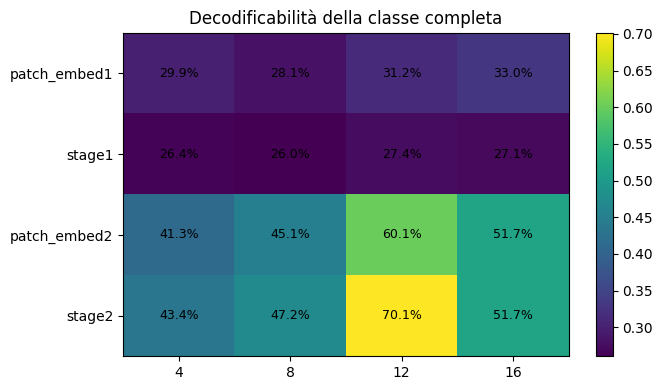

In [20]:
probe = pd.read_csv(phase2_audit / "aggregate_probe.csv")
layer_order = ["patch_embed1", "stage1", "patch_embed2", "stage2"]

full_class = probe[
    (probe["probe"] == "full_class")
    & (probe["content_pair"].isna())
].copy()

full_heat = full_class.pivot(
    index="layer",
    columns="timestep",
    values="audit_accuracy_mean",
).reindex(layer_order)

draw_heatmap(
    full_heat.values,
    full_heat.index.tolist(),
    [str(int(x)) for x in full_heat.columns],
    "Decodificabilità della classe completa",
    "24_phase2_probe_full_class",
)

peak_probe = full_class.loc[full_class["audit_accuracy_mean"].idxmax()]


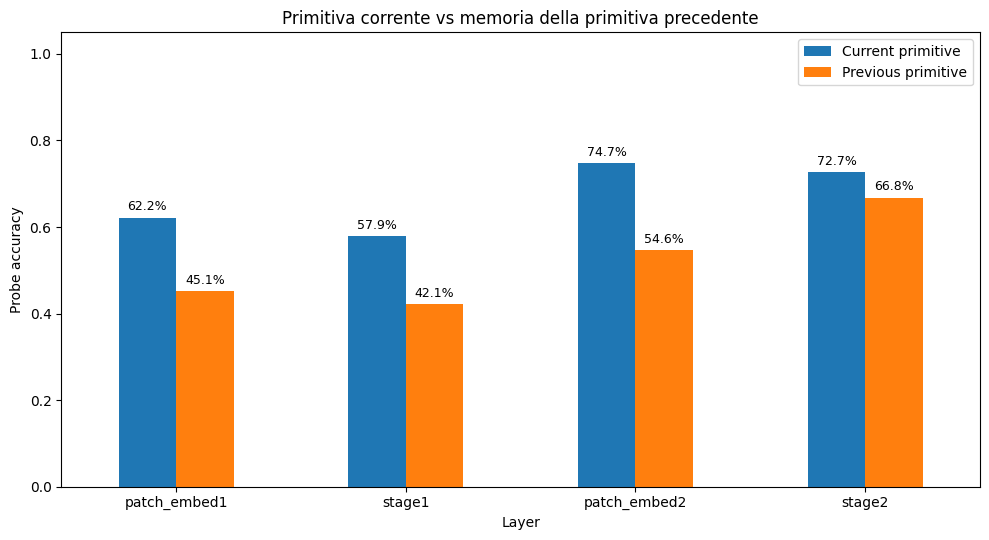

In [21]:
summary_probes = probe[
    probe["probe"].isin(["current_primitive", "previous_primitive"])
].copy()

probe_bar = summary_probes.pivot(
    index="layer",
    columns="probe",
    values="audit_accuracy_mean",
).reindex(layer_order)

fig, ax = plt.subplots(figsize=(10, 5.5))
probe_bar.plot(kind="bar", ax=ax)
ax.set_xlabel("Layer")
ax.set_ylabel("Probe accuracy")
ax.set_ylim(0, 1.05)
ax.set_title("Primitiva corrente vs memoria della primitiva precedente")
ax.legend(["Current primitive", "Previous primitive"])
ax.tick_params(axis="x", rotation=0)
annotate_bars(ax, percent=True)
save_and_show(fig, "25_phase2_probe_current_previous")

best_previous = summary_probes[
    summary_probes["probe"] == "previous_primitive"
].sort_values("audit_accuracy_mean", ascending=False).iloc[0]


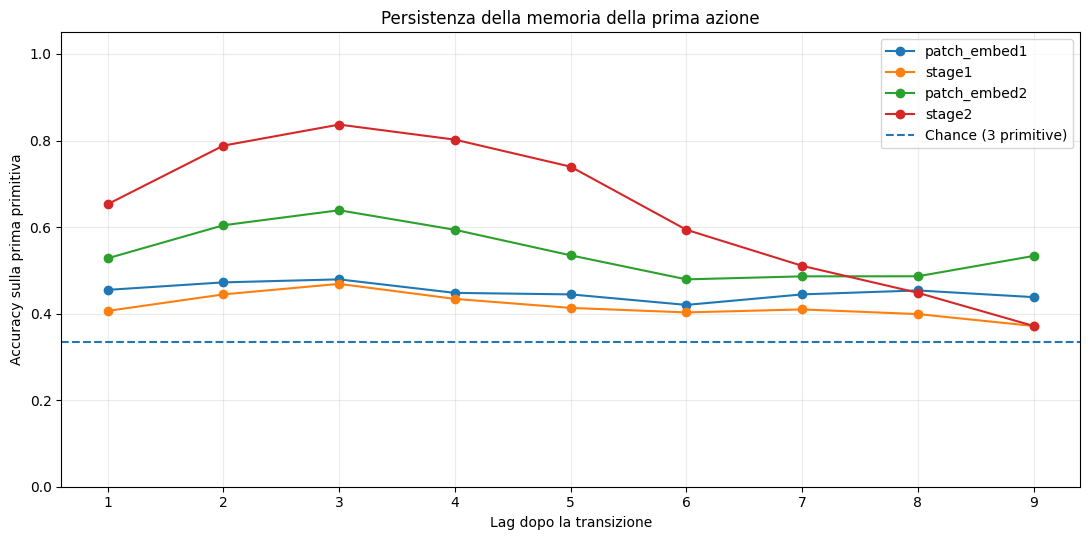

In [22]:
previous_lag = probe[
    probe["probe"] == "previous_primitive_by_lag"
].copy()

fig, ax = plt.subplots(figsize=(11, 5.5))
for layer in layer_order:
    group = previous_lag[previous_lag["layer"] == layer].sort_values("lag")
    ax.plot(
        group["lag"],
        group["audit_accuracy_mean"],
        marker="o",
        label=layer,
    )
ax.axhline(1 / 3, linestyle="--", label="Chance (3 primitive)")
ax.set_xticks(sorted(previous_lag["lag"].dropna().unique().astype(int)))
ax.set_xlabel("Lag dopo la transizione")
ax.set_ylabel("Accuracy sulla prima primitiva")
ax.set_ylim(0, 1.05)
ax.set_title("Persistenza della memoria della prima azione")
ax.legend()
ax.grid(alpha=0.25)
save_and_show(fig, "26_phase2_previous_primitive_by_lag")

stage2_lag = previous_lag[previous_lag["layer"] == "stage2"].sort_values("lag")
stage2_peak = stage2_lag.loc[stage2_lag["audit_accuracy_mean"].idxmax()]
stage2_last = stage2_lag.iloc[-1]


# Parte IV — L'informazione viene usata causalmente?

## 19. Activation patching

Per una coppia matched \(AB/BA\), una regione delle attivazioni di \(AB\) viene sostituita con quella del donor \(BA\).

Si osserva il margine:

\[
m = z_{AB} - z_{BA}
\]

e la variazione:

\[
\Delta m = m_{\text{patched}} - m_{\text{baseline}}.
\]

- \(\Delta m < 0\): il patch riduce il supporto per la classe originale e spinge verso l'inversa;
- \(\Delta m > 0\): il patch rafforza la classe originale o produce un effetto non coerente con l'inversione.

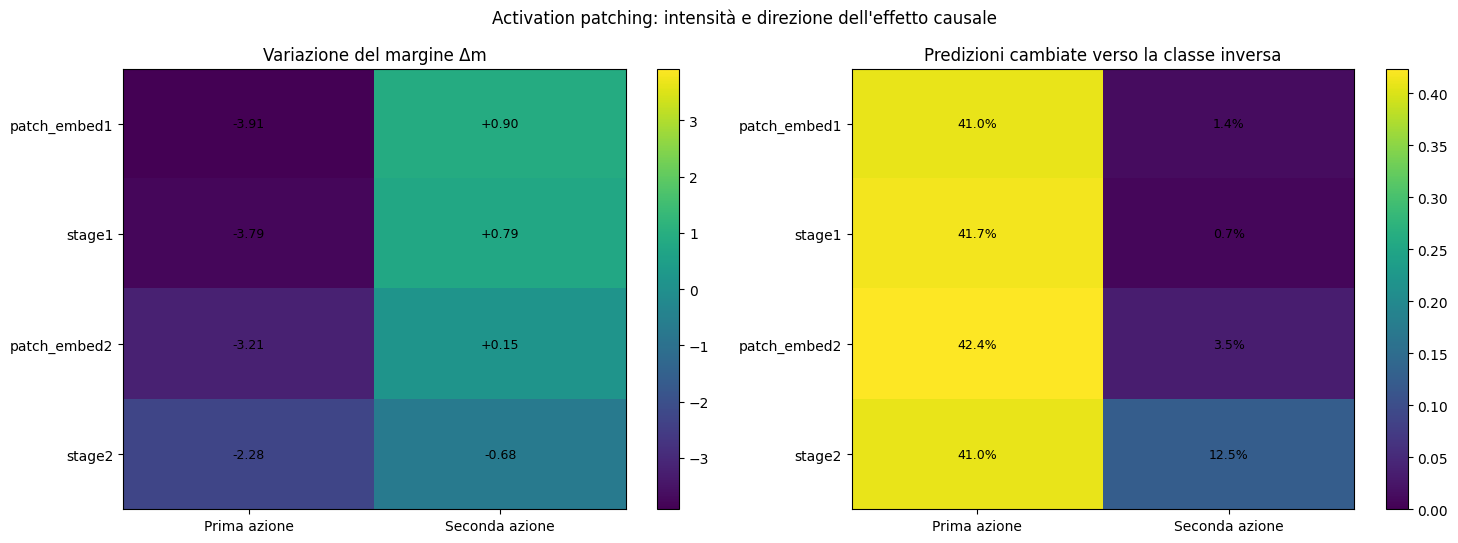

In [23]:
causal = pd.read_csv(phase2_audit / "aggregate_causal.csv")
causal_all = causal[causal["scope"] == "all_classes"].copy()

causal_margin = causal_all.pivot(
    index="layer",
    columns="region",
    values="mean_pairwise_margin_effect_mean",
).reindex(index=layer_order, columns=["first_action", "second_action"])

causal_inverse = causal_all.pivot(
    index="layer",
    columns="region",
    values="prediction_changed_to_inverse_rate_mean",
).reindex(index=layer_order, columns=["first_action", "second_action"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

margin_values = causal_margin.values.astype(float)
margin_limit = np.nanmax(np.abs(margin_values))
image_margin = axes[0].imshow(
    margin_values,
    aspect="auto",
    vmin=-margin_limit,
    vmax=margin_limit,
)
fig.colorbar(image_margin, ax=axes[0])
axes[0].set_xticks([0, 1], labels=["Prima azione", "Seconda azione"])
axes[0].set_yticks(np.arange(len(layer_order)), labels=layer_order)
axes[0].set_title("Variazione del margine Δm")
for i in range(margin_values.shape[0]):
    for j in range(margin_values.shape[1]):
        axes[0].text(
            j, i, f"{margin_values[i, j]:+.2f}",
            ha="center", va="center", fontsize=9
        )

inverse_values = causal_inverse.values.astype(float)
image_inverse = axes[1].imshow(
    inverse_values,
    aspect="auto",
    vmin=0,
    vmax=max(0.01, np.nanmax(inverse_values)),
)
fig.colorbar(image_inverse, ax=axes[1])
axes[1].set_xticks([0, 1], labels=["Prima azione", "Seconda azione"])
axes[1].set_yticks(np.arange(len(layer_order)), labels=layer_order)
axes[1].set_title("Predizioni cambiate verso la classe inversa")
for i in range(inverse_values.shape[0]):
    for j in range(inverse_values.shape[1]):
        axes[1].text(
            j, i, f"{100 * inverse_values[i, j]:.1f}%",
            ha="center", va="center", fontsize=9
        )

fig.suptitle("Activation patching: intensità e direzione dell'effetto causale")
save_and_show(fig, "27_28_phase2_causal_patching")

first_action_mean = causal_all[
    causal_all["region"] == "first_action"
]["mean_pairwise_margin_effect_mean"].mean()

second_action_rows = causal_all[
    causal_all["region"] == "second_action"
].sort_values("mean_pairwise_margin_effect_mean")
deepest_second = second_action_rows.iloc[0]
